In [1]:
import numpy as np
import matplotlib.pyplot as plt
import json
from pathlib import Path

In [51]:
# Caminho dos Datasets
path_data = Path("../../water_bottle_dataset/view_150")

view_normal = np.copy(np.load(path_data / "normal.npy", mmap_mode="r"))
view_depth = np.copy(np.load(path_data / "depth.npy", mmap_mode="r"))
view_rgb = np.copy(np.load(path_data / "rgb.npy", mmap_mode="r"))
view_seg = np.copy(np.load(path_data / "segmentation.npy", mmap_mode="r"))

In [52]:
# Function to visualize images
def visualize_dataset(rgb, normal, depth, seg):
    # Create a figure with subplots
    fig, axes = plt.subplots(1, 4, figsize=(20, 4))

    # 1. RGB Image
    axes[0].imshow(rgb)
    axes[0].set_title("RGB")
    axes[0].axis("off")

    # 2. Normal Map
    normal_vis = (normal - normal.min()) / (normal.max() - normal.min()) if normal.min() < 0 else normal
    axes[1].imshow(normal_vis)
    axes[1].set_title("Normal Map")
    axes[1].axis("off")

    # 3. Depth Map
    if depth.ndim == 3 and depth.shape[-1] == 1:
        depth = depth.squeeze(-1)  # Remove channel dimension if present
    axes[2].imshow(depth)
    axes[2].set_title("Depth")
    axes[2].axis("off")

    # 4. Segmentation Mask
    if seg.ndim == 3 and seg.shape[-1] == 1:
        seg = seg.squeeze(-1)
    axes[3].imshow(seg, cmap="tab20", interpolation="nearest")
    axes[3].set_title("Segmentation Mask")
    axes[3].axis("off")

    plt.tight_layout()
    plt.show()

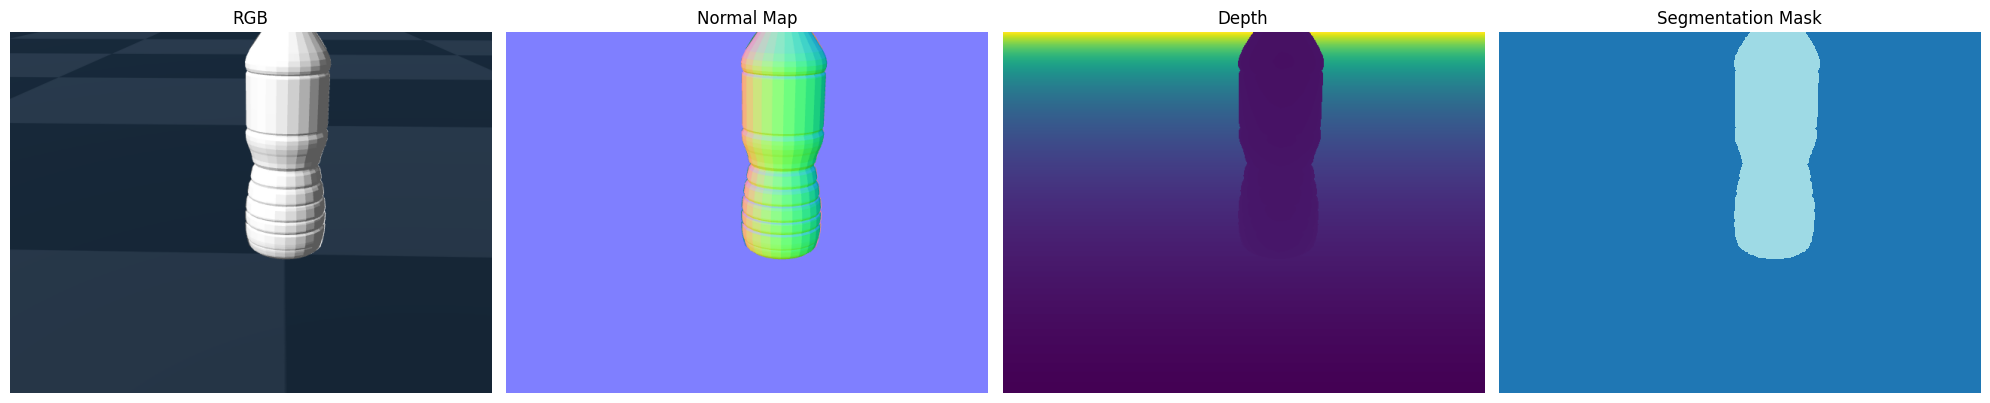

In [53]:
# Visualize all images
visualize_dataset(view_rgb, view_normal, view_depth, view_seg)

In [54]:
rgb_path = path_data / "rgb.npy"
rgb_path2 = path_data / "rgb.npy"
json_path = path_data  / "metadata.json"

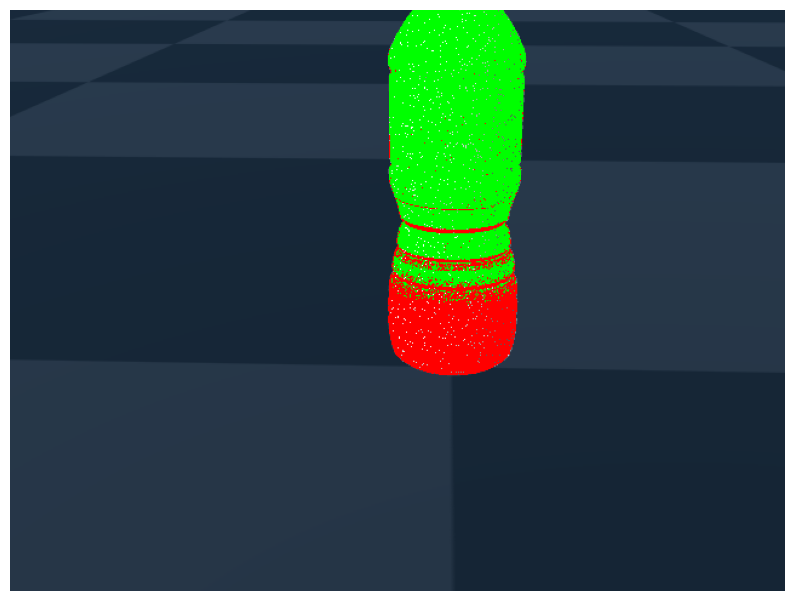

In [55]:
from PIL import Image

# Step 1: Load the JSON file
with open(json_path, 'r') as f:
    data = json.load(f)

# Extract contact data
final_contacts = data['final_contacts']
# Assuming random_x and random_y are in the JSON (not shown in provided snippet)
random_x = data['random_x']  # List of x-coordinates
random_y = data['random_y']  # List of y-coordinates

# Step 2: Load the RGB image
image = np.load(rgb_path)
#Image.open(rgb_path).convert('RGB')
image_np = np.array(image)

# Step 3: Create a copy of the image for overlay
overlay_image = image_np.copy()

# Step 4: Overlay contact information
green = [0, 255, 0]  # RGB for green
red = [255, 0, 0]    # RGB for red

for x, y, contact in zip(random_x, random_y, final_contacts):
    # Ensure coordinates are integers and within image bounds
    x, y = int(x), int(y)
    if 0 <= x < image_np.shape[1] and 0 <= y < image_np.shape[0]:
        overlay_image[y, x] = green if contact else red

# Step 5: Display the image
plt.figure(figsize=(10, 10))
plt.imshow(overlay_image)
plt.axis('off')  # Hide axes
plt.show()

JSON must be a list containing at least one dictionary
Missing key in JSON: 0


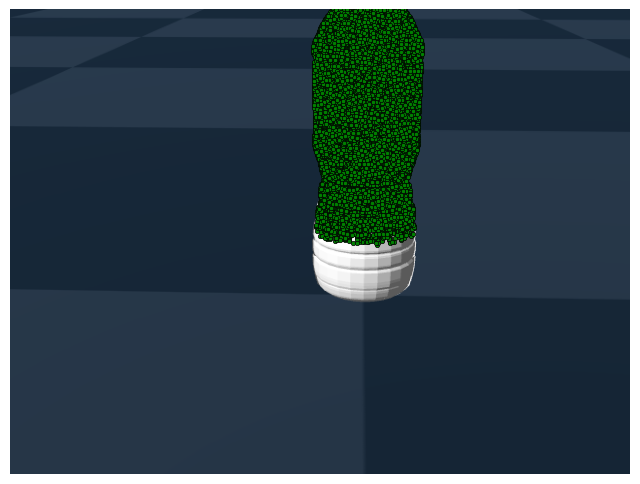

In [56]:
# Load JSON
try:
    with open(json_path, "r") as f:
        data = json.load(f)
except FileNotFoundError:
    print(f"JSON file not found at {json_path}")
    exit(1)
except json.JSONDecodeError:
    print("Invalid JSON format")
    exit(1)

# Check if data is a list with at least one dictionary
if not isinstance(data, list) or not data or not isinstance(data[0], dict):
    print("JSON must be a list containing at least one dictionary")
    exit(1)

# Extract lists from the first dictionary
try:
    final_contacts = data[0]["final_contacts"]
    random_x = data[0]["random_x"]
    random_y = data[0]["random_y"]
except KeyError as e:
    print(f"Missing key in JSON: {e}")
    exit(1)

# Check if lists are non-empty and have the same length
if not final_contacts or len(final_contacts) != len(random_x) or len(final_contacts) != len(random_y):
    print("JSON lists are empty or have mismatched lengths")
    exit(1)

# Filter True contacts
True_contacts = [(x, y) for x, y, contact in zip(random_x, random_y, final_contacts) if contact is True]
if not True_contacts:
    print("No True contacts found in JSON")
    exit(1)

# Unzip x, y coordinates
random_x, random_y = zip(*True_contacts)

# Load RGB image (optional)
try:
    view_rgb = np.load(rgb_path)
    if view_rgb.dtype != np.uint8 and view_rgb.max() <= 1:
        view_rgb = (view_rgb * 255).astype(np.uint8)
except FileNotFoundError:
    print(f"RGB image not found at {rgb_path}; using blank canvas")
    view_rgb = None
    H, W = 480, 640  # Default image size, adjust if needed
else:
    H, W = view_rgb.shape[:2]

# Filter valid coordinates
valid = [(x, y) for x, y in zip(random_x, random_y) if 0 <= x < W and 0 <= y < H]
if not valid:
    print("No valid True contacts within image bounds")
    exit(1)
random_x, random_y = zip(*valid)

# Plot
fig, ax = plt.subplots(figsize=(8, 8))
if view_rgb is not None:
    ax.imshow(view_rgb)
else:
    ax.set_xlim(0, W)
    ax.set_ylim(H, 0)

# Plot only True contacts (red points)
ax.scatter(random_x, random_y, c="green", s=10, edgecolors="black", linewidth=0.5)

# Remove axis
ax.axis("off")

plt.show()